In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from cooltools.lib import plotting
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
import seaborn as sns
import pandas as pd

from functools import reduce

from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture


In [2]:
import pybedtools as pbt

In [3]:
basedir = os.getcwd()
print(basedir)

%cd /home/varshini/uc_analyses/
import calc_insulation
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

/home/varshini/LoopCall_Analysis_Scripts/blood/complete_analyses/FigureGeneration
/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 14})

In [5]:
phases = ['Phase1_', 'Phase2_dedup', 'Phase3_dedup']
res = 10_000
ins_res = 10_000

uc_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
uc_filenames = [os.path.join(uc_path, f"Sankaran_{p}merged.250.mcool") for p in phases]
uc_coolers = [utils.get_clr(clr_name, res) for clr_name in uc_filenames]

In [6]:
basedir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/boundaries/'
insulation_filenames = [os.path.join(basedir, f"{p}_microc_insulation_{ins_res}bp.tsv") for p in phases]
merged_insulation_filename = 'merged_boundary_strengths.tsv'

In [7]:
savedir = '/mnt/md0/varshini/Analysis/Blood/figs_v2/fig1'

In [8]:
def merge_boundaries(insulation_files, merge_method='outer'):
    og_cols = insulation_files[0].columns
    ins = []
    for j in range(len(insulation_files)):
        ins.append(insulation_files[j].rename(columns={c: c+f'_{j+1}' for c in insulation_files[j].columns[4:]}))
    #print(ins)
    
    outer_merged_boundaries = reduce(lambda left,right: pd.merge(left,right,on=['chrom', 'start','end', 'region'], how=merge_method), ins)
    #print(outer_merged_boundaries)
    
    # for every window, keep any interval where any phase has a boundary at that window
    # save as window-specific files
    
    windows = set([num for num in [col.split('_')[-1] for col in og_cols] if num.isdigit()])
    window_df = {}
    
    for w in windows:
        # subset merged df on columns 5+ for containing the numeric w 
        cols = [col for col in outer_merged_boundaries.columns if w in col]

        cols_to_keep = outer_merged_boundaries.columns[:5].to_list()
        cols_to_keep.extend(cols)
        #print(cols_to_keep)
        sub_df = outer_merged_boundaries[cols_to_keep]
        #print(sub_df)
        
        # keep only where any column containing boundary_strength_{w} is True 
        boundary_cols = [col for col in cols if f'is_boundary_{w}' in col]
        sub_df = sub_df[sub_df[boundary_cols].any(axis=1)]
        
        print(sub_df)
        # save the window df and append it to the dict as well? just append for now, or add save method
        window_df[w] = sub_df
    
    return window_df



In [11]:
insulation_files = [pd.read_csv(i, sep='\t') for i in insulation_filenames]

In [12]:
window_df = merge_boundaries(insulation_files)

       chrom      start        end  region  is_bad_bin_1  \
87      chr1     870000     880000  chr1_p         False   
97      chr1     970000     980000  chr1_p         False   
98      chr1     980000     990000  chr1_p         False   
111     chr1    1110000    1120000  chr1_p         False   
112     chr1    1120000    1130000  chr1_p         False   
...      ...        ...        ...     ...           ...   
303032  chrX  155210000  155220000  chrX_q         False   
303065  chrX  155540000  155550000  chrX_q         False   
303076  chrX  155650000  155660000  chrX_q         False   
303091  chrX  155800000  155810000  chrX_q         False   
303095  chrX  155840000  155850000  chrX_q         False   

        log2_insulation_score_50000_1  n_valid_pixels_50000_1  \
87                           0.529991                    17.0   
97                           0.455525                    22.0   
98                           0.472580                    22.0   
111                

In [24]:
w=100_000
test_ins = window_df[str(w)]

In [25]:

def extract_TADs(insulation_table, is_boundary_col, MAX_TAD_LENGTH = 3_000_000):
    tads = bioframe.merge(insulation_table[insulation_table[is_boundary_col] == False])
    return tads[ (tads["end"] - tads["start"]) <= MAX_TAD_LENGTH].reset_index(drop=True)[['chrom','start','end']]

for i in range(3):
    TADs_table = extract_TADs(insulation_files[0], f'is_boundary_{w}')
    

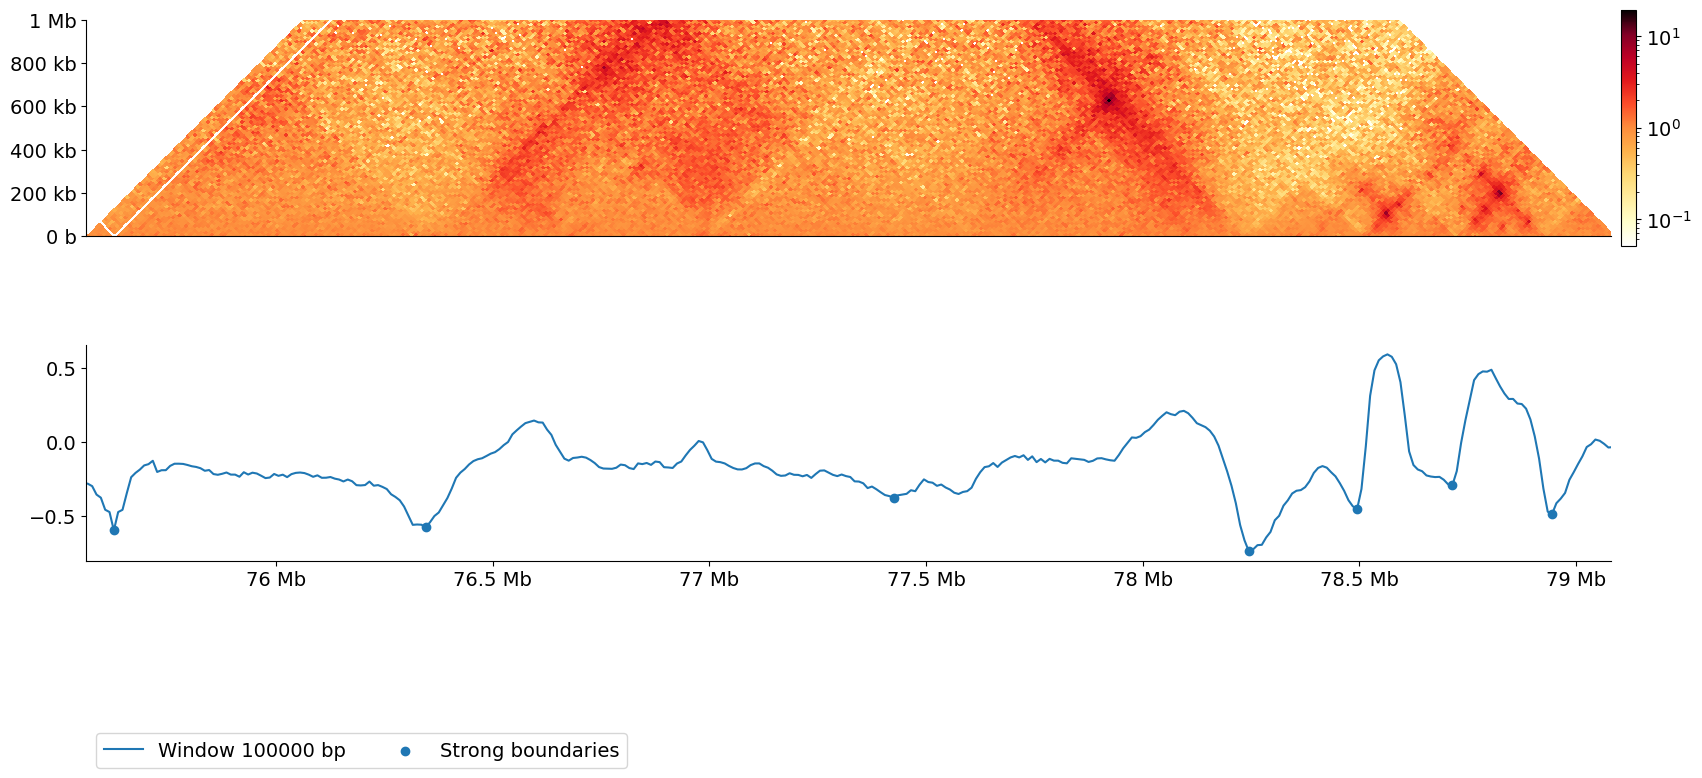

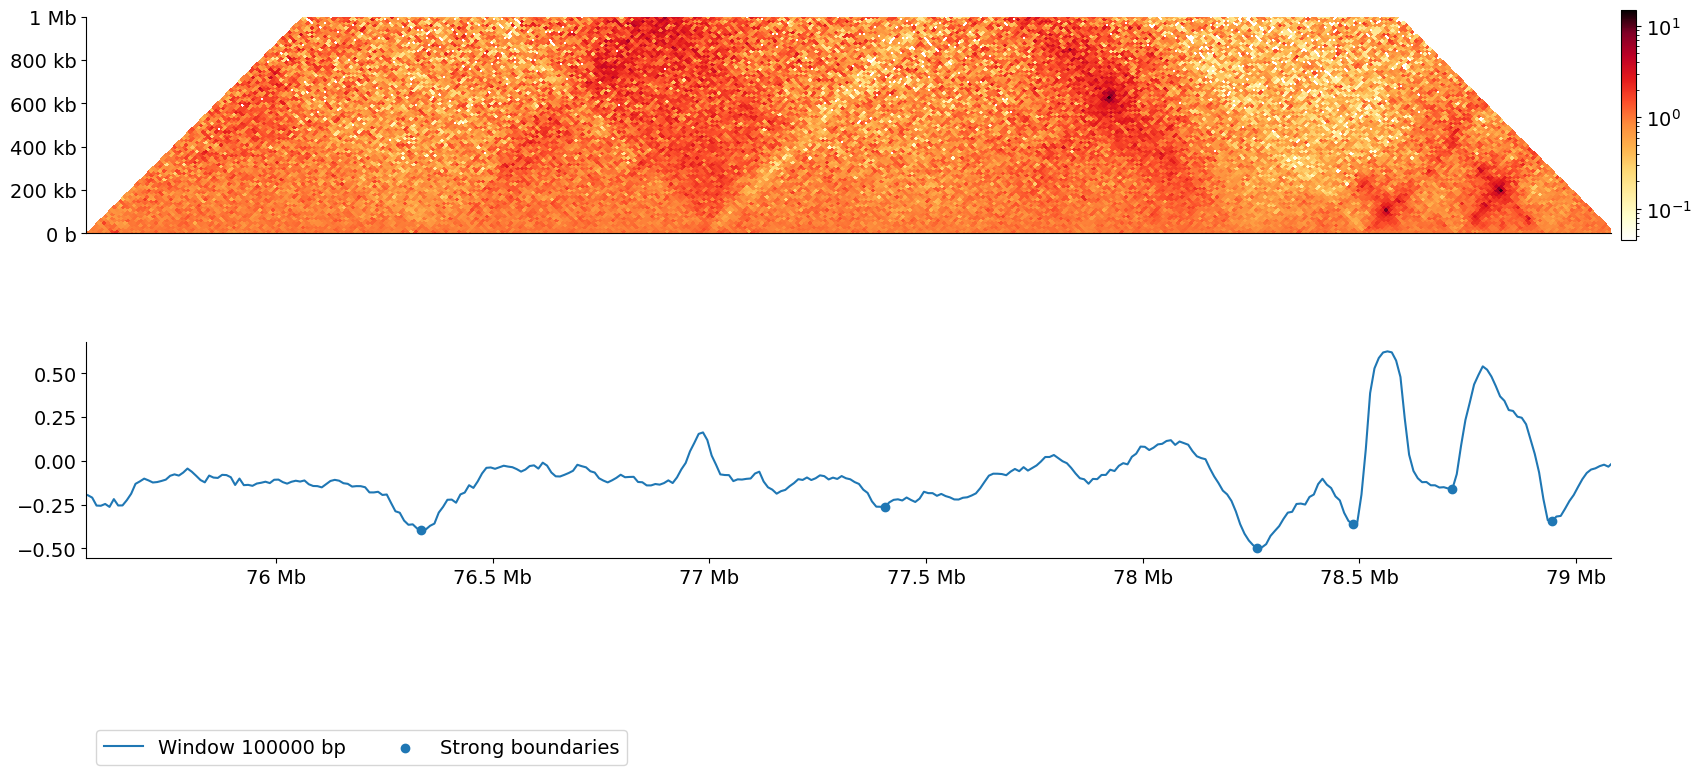

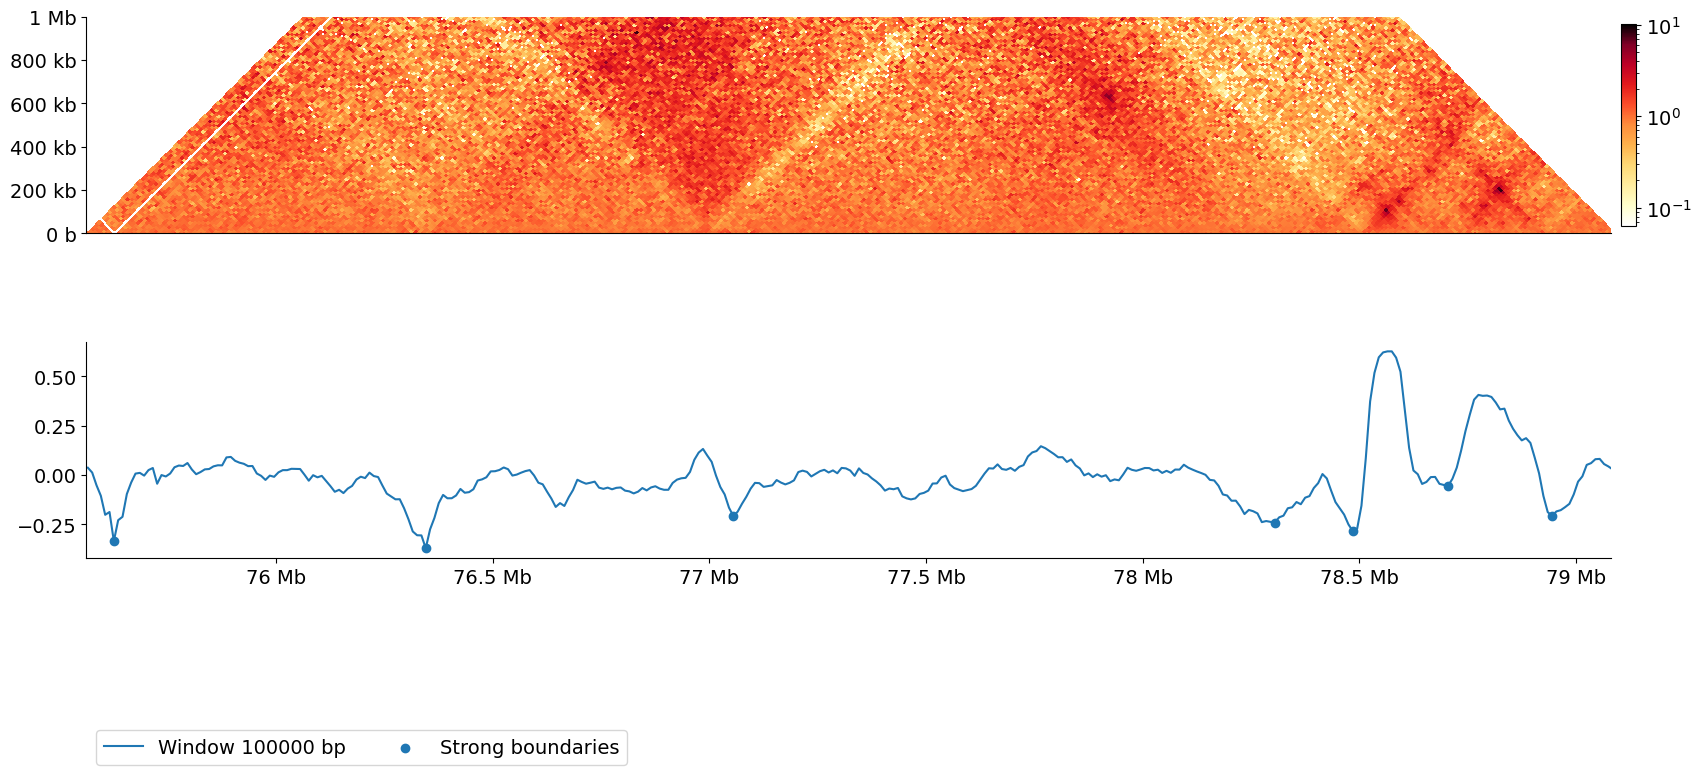

In [26]:
# 
reg = 'chr8:75561811-79081548'

i=0
for clr, ins in zip(uc_coolers, insulation_files):
    calc_insulation.plot_insulation_boundary(utils.get_matr(clr, utils.get_coords(reg)), ins, \
                                             [w], utils.get_coords(reg), res=10000, norm=None, off_diag=1000,
                                            plot_weak_bounds=False, sd=None)
    i+=1

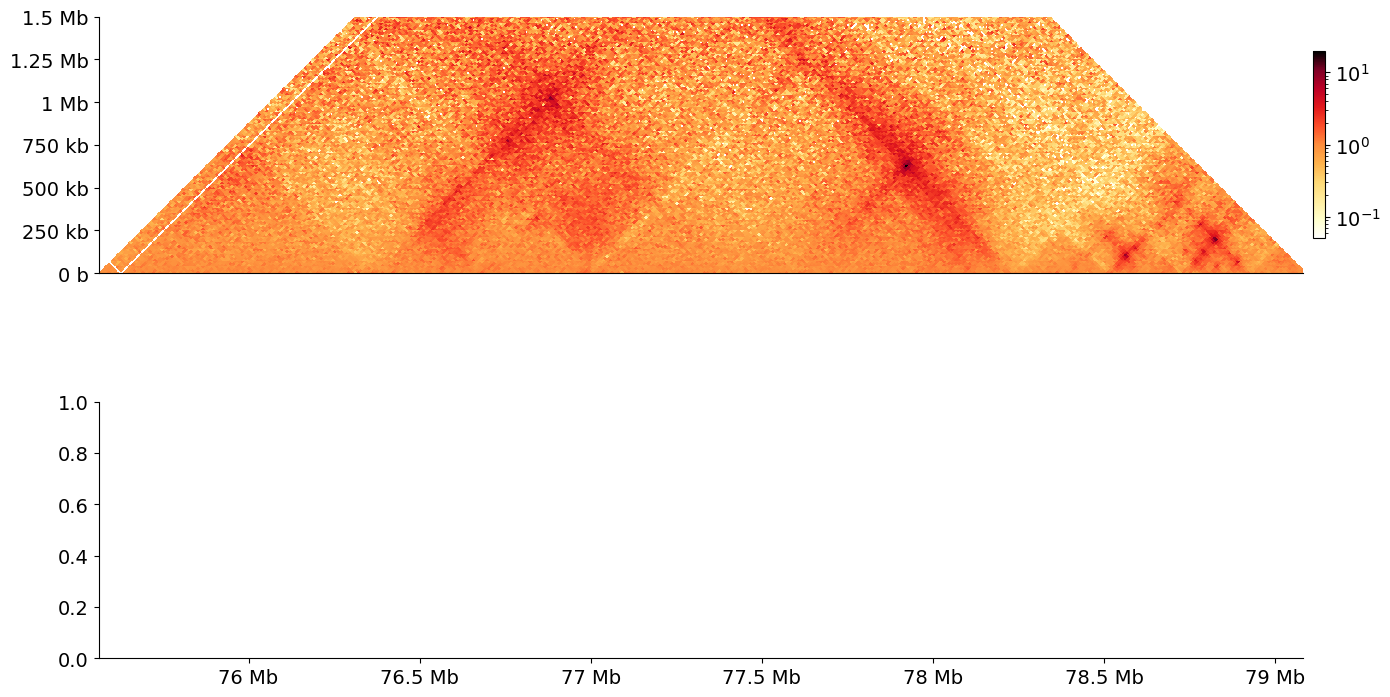

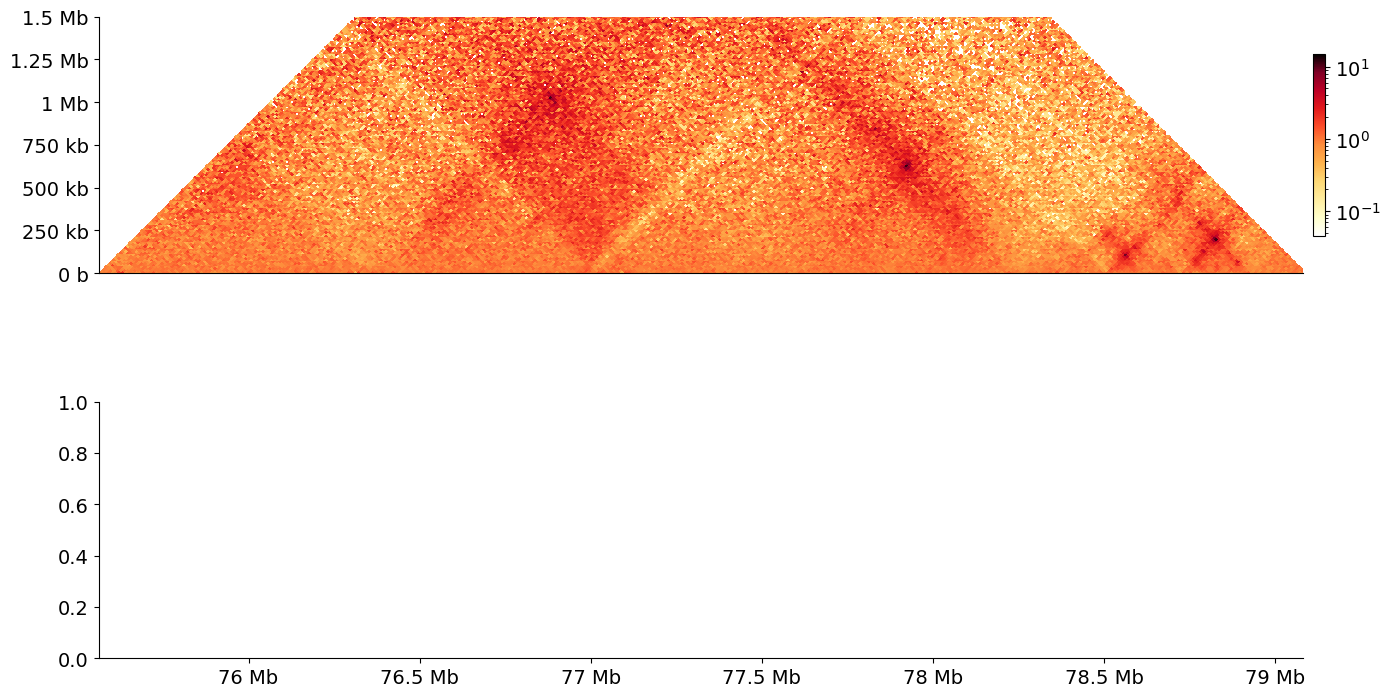

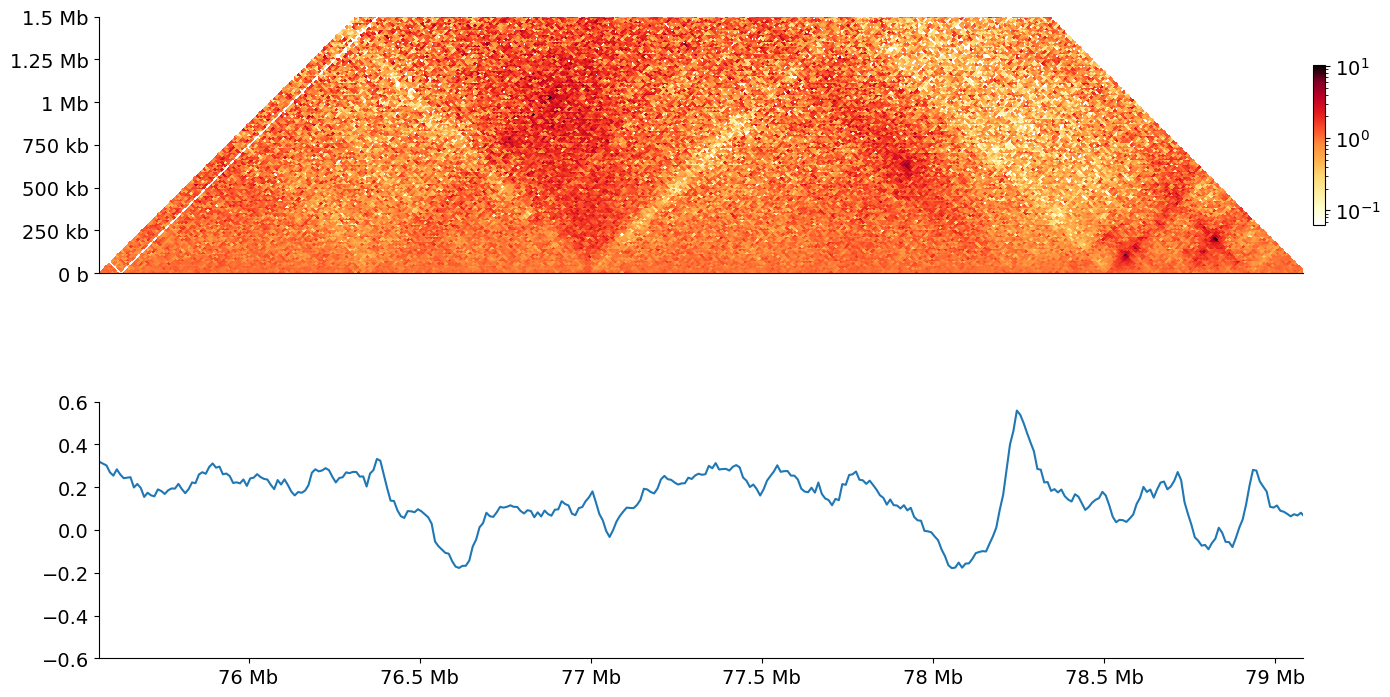

In [27]:
reg = 'chr8:75561811-79081548'
i=0
sd=f"/mnt/md0/varshini/Analysis/Blood/figs_v2/fig1_ins_log2FC_10kbb_{w//1000}kbw.svg"
sd=None
windows=[100_000]
plot_weak_bounds=False
ins_score = []
for clr, ins in zip(uc_coolers, insulation_files):
    f, ax, im, insul_region, ins_ax = calc_insulation.plot_insulation_base(utils.get_matr(clr, utils.get_coords(reg)),
                                                                           ins,
                                                                           1500,utils.get_coords(reg), res=10000, 
                                                                           norm=None,ylim=None
                                                                           )
    ins_score.append(insul_region[f'log2_insulation_score_{windows[0]}'])
    i+=1

ins_FC_31 = (ins_score[2]-ins_score[0])
ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
                ins_FC_31, label=f'Window {windows[0]} bp')
ins_ax.set_ylim([-0.6, 0.6])
#ins_ax.scatter(strong_boundaries[['start', 'end']].mean(axis=1),
#                   strong_boundaries[f'log2_insulation_score_{windows[0]}'], label='Strong boundaries')

if sd is None:
    plt.show()
else:
    plt.savefig(sd)

